# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

**Question 1:**

1. We use them because many real outcomes are not well modeled by a straight-line relationship. They let us transform a linear score into something more useful, such as a probability between 0 and 1. This makes them better than ordinary linear models for classification problems.

2. They are effective because logistic regression predicts probabilities. Cross entropy measures how close those predicted probabilities are to the true outcomes. It gives a large penalty when the model is very confident and wrong, so it helps fit the model well.

3. True. It is linear in the predictors at the level of the log-odds. The predicted probability is not linear, but the underlying model is still linear.

4. False. Logistic regression is often used for classification. It predicts probabilities, and we can convert those probabilities into class labels.

5. No. The coefficient shows the change in the log-odds, not the direct change in probability. The change in probability depends on where you are on the logistic curve.

6. False. Even though logistic regression gives a nonlinear probability, it is still linear in the predictors. So feature engineering can still be useful.

7. False. Logistic regression is better when the outcome is binary or categorical. Ordinary least squares is still better when the outcome is continuous. The right model depends on the problem.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [1]:
! git clone https://github.com/anishjagota/undergrad_ml_assignments

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 185, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 185 (delta 2), reused 0 (delta 0), pack-reused 179 (from 2)
Receiving objects: 100% (185/185), 15.98 MiB | 16.92 MiB/s, done.
Resolving deltas: 100% (76/76), done.


In [7]:
#2.1
import pandas as pd
import numpy as np

df = pd.read_csv('/content/undergrad_ml_assignments/data/data.csv', sep=';')[
    ['Debtor', 'Tuition fees up to date', 'Scholarship holder',
     'Age at enrollment', 'Curricular units 1st sem (approved)', 'Target']
].dropna()

df['dropout_binary'] = (df['Target'] == 'Dropout').astype(int)

print(df.isna().sum())
df.head()

Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dropout_binary                         0
dtype: int64


,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,dropout_binary
0,0,1,0,20,0,Dropout,1
1,0,0,0,19,6,Graduate,0
2,0,0,0,19,0,Dropout,1
3,0,1,0,20,6,Graduate,0
4,0,1,0,45,5,Graduate,0


I checked for missing values and found that all selected variables had 0 missing values, so no additional cleaning was necessary.

In [10]:
#2.2
X = df[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']]
y = df['dropout_binary']

logit = LogisticRegression(max_iter=5000)
logit.fit(X, y)

coef_table = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': logit.coef_[0]
})

coef_table

,Variable,Coefficient
0,Debtor,0.530625
1,Tuition fees up to date,-2.556542
2,Scholarship holder,-1.227442
3,Age at enrollment,0.049925


The logistic regression suggests that Debtor and Age at enrollment predict a higher probability of dropout because their coefficients are positive. In contrast, Tuition fees up to date and Scholarship holder predict a lower probability of dropout because their coefficients are negative. The strongest negative coefficient is for Tuition fees up to date (-2.556542), which suggests that being up to date on tuition is strongly associated with lower dropout risk. So yes, being up to date on tuition does seem to reduce dropout probability.

In [11]:
#2.3
plot_df = df[['Age at enrollment', 'Tuition fees up to date']].copy()
plot_df['p_hat'] = logit.predict_proba(X)[:, 1]

avg_effect = (
    plot_df.groupby('Tuition fees up to date')['p_hat']
    .mean()
    .rename({0: 'Not up to date', 1: 'Up to date'})
)

print(avg_effect)
print('\nAverage difference (Up to date - Not up to date):',
      avg_effect['Up to date'] - avg_effect['Not up to date'])

Tuition fees up to date
Not up to date    0.860675
Up to date        0.248090
Name: p_hat, dtype: float64

Average difference (Up to date - Not up to date): -0.6125849339840048


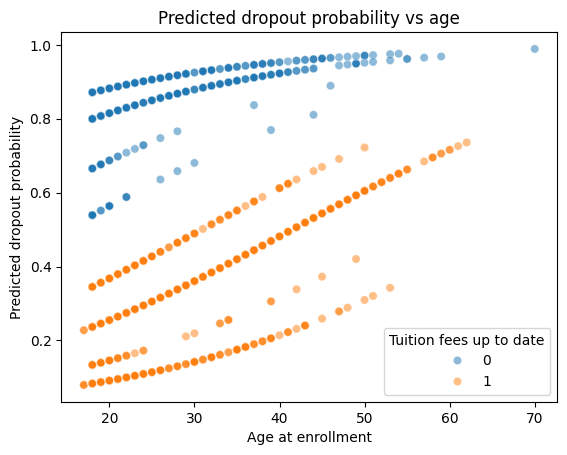

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=plot_df,
    x='Age at enrollment',
    y='p_hat',
    hue='Tuition fees up to date',
    alpha=0.5
)

plt.xlabel('Age at enrollment')
plt.ylabel('Predicted dropout probability')
plt.title('Predicted dropout probability vs age')
plt.show()

Students who are not up to date on tuition have much higher predicted dropout probabilities than students who are up to date on tuition at nearly all ages.

The effect of being up to date on tuition appears strongest across the full age range shown, since the two groups are clearly separated in the plot. On average, predicted dropout probability is 0.861 for students not up to date and 0.248 for students up to date. The average difference is -0.613, so being up to date on tuition lowers predicted dropout probability by about 61.3 percentage points on average.

In [17]:
#2.4
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = logit.predict(X)
cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)
print("Confusion matrix:")
print(cm)
print("\nAccuracy:", acc)

Confusion matrix:
[[2841  162]
 [ 891  530]]

Accuracy: 0.7619801084990958


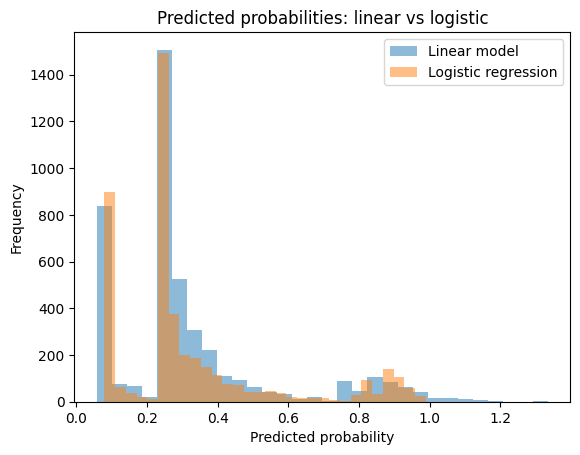

Linear model min/max: 0.05832035022573856 1.3349535706758708
Logistic model min/max: 0.0794707837723452 0.9891329873410378


In [18]:
#2.5
from sklearn.linear_model import LinearRegression
lin = LinearRegression()
lin.fit(X, y)
p_hat_lin = lin.predict(X)
p_hat_logit = logit.predict_proba(X)[:, 1]

plt.hist(p_hat_lin, bins=30, alpha=0.5, label='Linear model')
plt.hist(p_hat_logit, bins=30, alpha=0.5, label='Logistic regression')
plt.xlabel('Predicted probability')
plt.ylabel('Frequency')
plt.title('Predicted probabilities: linear vs logistic')
plt.legend()
plt.show()
print("Linear model min/max:", p_hat_lin.min(), p_hat_lin.max())
print("Logistic model min/max:", p_hat_logit.min(), p_hat_logit.max())

The linear model is less appropriate because its predicted values range from about 0.058 to 1.335, so some are greater than 1 and cannot be valid probabilities.

Question 2.6:

Students most at risk of dropping out are those who have outstanding debt, are not up to date on tuition, are not scholarship holders, and are older at enrollment. Possible interventions are could be financial aid or emergency tuition support, early advising, and payment plans for student with debt.

In [19]:
# 2.7
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
import pandas as pd

X_multi = df[['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']]
y_multi = df['Target']

multi = LogisticRegression(max_iter=5000, multi_class='multinomial')
multi.fit(X_multi, y_multi)

# hard classification
y_multi_pred = multi.predict(X_multi)
cm_multi = confusion_matrix(y_multi, y_multi_pred, labels=multi.classes_)
acc_multi = accuracy_score(y_multi, y_multi_pred)

print("Classes:", multi.classes_)
print("\nConfusion matrix:")
print(pd.DataFrame(cm_multi, index=multi.classes_, columns=multi.classes_))
print("\nAccuracy:", acc_multi)

# predicted probabilities
proba_multi = pd.DataFrame(
    multi.predict_proba(X_multi),
    columns=multi.classes_
)

print("\nPredicted probabilities (first 5 rows):")
print(proba_multi.head())

print("\nAny class ever predicted by hard classification?")
print(pd.Series(y_multi_pred).value_counts())

print("\nLargest predicted probability by class:")
print(proba_multi.idxmax(axis=1).value_counts())

Classes: ['Dropout' 'Enrolled' 'Graduate']

Confusion matrix:
          Dropout  Enrolled  Graduate
Dropout      1054         0       367
Enrolled      280         0       514
Graduate      146         0      2063

Accuracy: 0.7045660036166366

Predicted probabilities (first 5 rows):
    Dropout  Enrolled  Graduate
0  0.680547  0.210464  0.108989
1  0.695414  0.146043  0.158543
2  0.952988  0.041199  0.005813
3  0.117808  0.176983  0.705209
4  0.184227  0.212669  0.603104

Any class ever predicted by hard classification?
Graduate    2944
Dropout     1480
Name: count, dtype: int64

Largest predicted probability by class:
Graduate    2944
Dropout     1480
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


The multinomial logistic regression has an accuracy of 0.705. The confusion matrix shows that the model predicts Dropout and Graduate, but it does not predict Enrolled at all. Every Enrolled observation is classified as either Dropout or Graduate.

The predicted probabilities also do not make Enrolled the largest predicted class for any observation. So the hard classifications do not predict every class, and the predicted probabilities do not effectively predict every class either.Overall, the model does a reasonable job for Graduate and somewhat for Dropout, but it performs poorly for Enrolled.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [22]:
# Q3.1
import pandas as pd
import numpy as np
df = pd.read_csv('/content/undergrad_ml_assignments/data/cirrhosis.csv')
df = df[['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']].dropna().copy()
df['survival_binary'] = df['Status'].isin(['C', 'CL']).astype(int)
print(df.isna().sum())
df.head()

Bilirubin          0
Edema              0
Drug               0
Stage              0
Status             0
survival_binary    0
dtype: int64


,Bilirubin,Edema,Drug,Stage,Status,survival_binary
0,14.5,Y,D-penicillamine,4.0,D,0
1,1.1,N,D-penicillamine,3.0,C,1
2,1.4,S,D-penicillamine,4.0,D,0
3,1.8,S,D-penicillamine,4.0,D,0
4,3.4,N,Placebo,3.0,CL,1


I loaded cirrhosis.csv, kept the variables Bilirubin, Edema, Drug, Stage, and Status, and dropped rows with missing values. There were no missing values in the filtered dataset. I then created a binary survival variable where C and CL were coded as 1 (alive) and D was coded as 0 (dead).

In [21]:
# Q3.2
X = pd.get_dummies(df[['Edema', 'Drug', 'Bilirubin']], drop_first=True)
y = df['survival_binary']
from sklearn.linear_model import LogisticRegression
logit = LogisticRegression(max_iter=5000)
logit.fit(X, y)

coef_table = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': logit.coef_[0]
})

coef_table

,Variable,Coefficient
0,Bilirubin,-0.351424
1,Edema_S,-0.450677
2,Edema_Y,-1.611049
3,Drug_Placebo,0.231225


The logistic regression suggests that higher bilirubin predicts a lower survival probability, since its coefficient is negative:-0.351.For edema, survival gets worse as edema becomes more severe. Relative to no edema. Edema_S has a negative coefficient (-0.451), so resolvable edema is associated with lower survival. Edema_Y has a more negative coefficient (-1.611), so severe edema is associated with much lower survival.

In [23]:
# Q3.3
plot_df = df[['Bilirubin', 'Drug']].copy()
plot_df['p_hat'] = logit.predict_proba(X)[:, 1]
avg_survival = (
    plot_df.groupby('Drug')['p_hat']
    .mean()
    .sort_values(ascending=False)
)

print(avg_survival)
if len(avg_survival) == 2:
    print("\nAverage difference:",
          avg_survival.iloc[0] - avg_survival.iloc[1])

Drug
Placebo            0.608902
D-penicillamine    0.590054
Name: p_hat, dtype: float64

Average difference: 0.01884850103850899


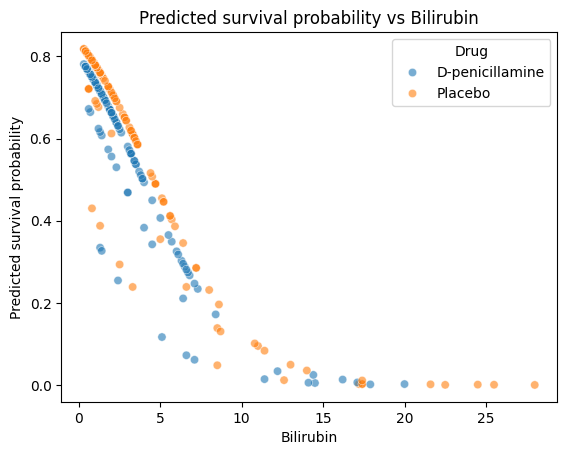

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=plot_df,
    x='Bilirubin',
    y='p_hat',
    hue='Drug',
    alpha=0.6
)

plt.xlabel('Bilirubin')
plt.ylabel('Predicted survival probability')
plt.title('Predicted survival probability vs Bilirubin')
plt.show()

The drug does not seem to increase survival for any bilirubin level. The placebo group has consistently slightly higher predicted survival probabilities across the range of bilirubin values.

In [25]:
# 3.4
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = logit.predict(X)
cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)
print("Confusion matrix:")
print(cm)
print("\nAccuracy:", acc)

Confusion matrix:
[[ 59  66]
 [ 16 171]]

Accuracy: 0.7371794871794872


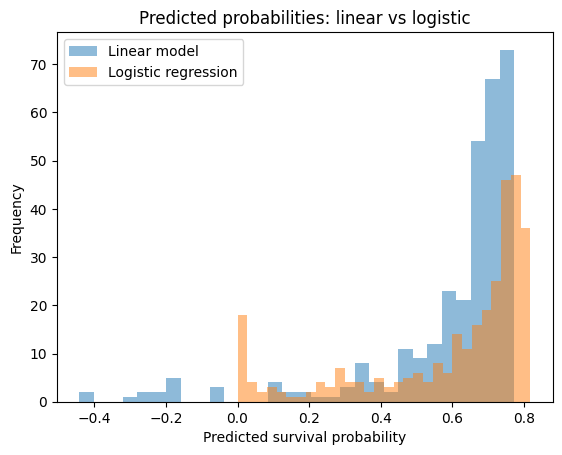

Linear model min/max: -0.4417396683935991 0.7738680250928711
Logistic model min/max: 0.00017000836983990482 0.8184120388871089


In [26]:
# 3.5
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
lin = LinearRegression()
lin.fit(X, y)
p_hat_lin = lin.predict(X)
p_hat_logit = logit.predict_proba(X)[:, 1]

plt.hist(p_hat_lin, bins=30, alpha=0.5, label="Linear model")
plt.hist(p_hat_logit, bins=30, alpha=0.5, label="Logistic regression")
plt.xlabel("Predicted survival probability")
plt.ylabel("Frequency")
plt.title("Predicted probabilities: linear vs logistic")
plt.legend()
plt.show()
print("Linear model min/max:", p_hat_lin.min(), p_hat_lin.max())
print("Logistic model min/max:", p_hat_logit.min(), p_hat_logit.max())

The linear model gives predicted values from -0.442 to 0.774, so it produces impossible probabilities below 0. The logistic model gives predicted probabilities from 0.00017 to 0.818, which all stay between 0 and 1. So, logistic regression performs better for probability prediction, because its fitted values are valid probabilities, while the linear model can produce invalid ones.

In [27]:
# 3.6
from sklearn.linear_model import LogisticRegression
import pandas as pd

X_stage = pd.get_dummies(df[['Edema', 'Bilirubin']], drop_first=True)
y_stage = df['Stage'].astype(int)
multi = LogisticRegression(multi_class='multinomial', max_iter=5000)
multi.fit(X_stage, y_stage)
stage_pred = multi.predict(X_stage)
stage_prob = pd.DataFrame(
    multi.predict_proba(X_stage),
    columns=multi.classes_
)
cm_stage = pd.crosstab(
    pd.Series(y_stage, name='Actual'),
    pd.Series(stage_pred, name='Predicted')
)
acc_stage = (stage_pred == y_stage).mean()
print("Classes:", multi.classes_)
print("\nConfusion matrix:")
print(cm_stage)
print("\nAccuracy:", acc_stage)
print("\nPredicted probabilities (first 5 rows):")
print(stage_prob.head())
print("\nHard classification counts:")
print(pd.Series(stage_pred).value_counts().sort_index())
print("\nLargest predicted-probability class counts:")
print(stage_prob.idxmax(axis=1).value_counts().sort_index())

Classes: [1 2 3 4]

Confusion matrix:
Predicted    3   4
Actual            
1           16   0
2           63   4
3          105  15
4           79  30

Accuracy: 0.4326923076923077

Predicted probabilities (first 5 rows):
          1         2         3         4
0  0.000013  0.032535  0.143611  0.823841
1  0.072394  0.251555  0.397520  0.278531
2  0.029263  0.181531  0.395694  0.393512
3  0.023272  0.176777  0.397217  0.402734
4  0.020204  0.224965  0.423342  0.331488

Hard classification counts:
3    263
4     49
Name: count, dtype: int64

Largest predicted-probability class counts:
3    263
4     49
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


The multinomial logistic regression has an accuracy of 0.433, so it correctly predicts about 43.3% of cases. The model does not predict every stage. In the hard classification results, it only predicts Stage 3 and Stage 4. It never predicts Stage 1 or Stage 2. The predicted probabilities include all four stages, since the model gives a probability for 1, 2, 3, and 4. However, the largest predicted probability is only ever for Stage 3 or Stage 4.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

**Question 4:**

1. For the linear model, the predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^{K} b_k x_k
$$

The derivative of the prediction with respect to the k-th feature is:
$$
\frac{\partial \hat{y}}{\partial x_k} = b_k
$$
So, for a 1-unit increase in $x_k$, the prediction changes by exactly $b_k$. This effect is constant and does not depend on $x$.


2. For the logistic model, the predictions are:
$$
\hat{p} = \frac{e^{b \cdot x}}{1 + e^{b \cdot x}}
$$

The derivative with respect to the $k$-th feature is:
$$
\frac{\partial \hat{p}}{\partial x_k} = \hat{p}(1-\hat{p})b_k
$$

So, for a 1-unit increase in $x_k$, the predicted probability changes by
$$
\hat{p}(1-\hat{p})b_k
$$

Unlike the linear model, this effect is not constant. It depends on the value of $\hat{p}$, so it changes as $x$ changes.

This is similar to part 1 because the coefficient $b_k$ still matters, but it is different because in logistic regression the effect on the prediction is scaled by $\hat{p}(1-\hat{p})$. Since $\hat{p}(1-\hat{p})$ is largest when $\hat{p}=0.5$, the coefficient itself times 4 is a roughly good estimate when $\hat{p}$ is near 0.5.



3.
$$
\log\left(\frac{\hat{p}}{1-\hat{p}}\right)= b \cdot x
$$

The left-hand side is the **log odds ratio**, and the right-hand side is the latent variable.

A 1-unit increase in $x_k$ changes the log odds ratio by exactly $b_k$

So, the coefficient $b_k$ in logistic regression is interpreted as the change in the log-odds of the outcome for a 1-unit increase in $x_k$, holding the other variables fixed.